In [4]:
#import relevant libraries
#Load modules
import os
import pandas as pd
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns
import dabest
from struct import *
import osar
import scipy as sp
import re
import dabest

import warnings
from datetime import datetime
import scikits.bootstrap as skb
from osar.plot_helpers.plot_helpers import r2_and_slope
date = datetime.today().strftime('%Y%m%d')

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

In [10]:
basegenotype = "SS95118"
responder = "ACR"
wt = "w1118"
addNotes = basegenotype + " x " + responder
trans = addNotes

officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
computer3 = "D:\\"
filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\"
specifiedpath = labcomp

baseDirectory_OSAR = specifiedpath + filedirectory_OSAR + addNotes


#OSAR related files
if len(addNotes) > 0:
    addNotes = "_" + addNotes   
filename_O = baseDirectory_OSAR + "\\" + basegenotype
filename_AppendDT = "_gen " + date
filename_O = filename_O + addNotes + filename_AppendDT

filename_O

'C:\\Users\\User\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\OSAR\\SS95118 x ACR\\SS95118_SS95118 x ACR_gen 20250310'

In [6]:
def singleplottingdabest(dfi, names, parameter):
    dfrr = pd.DataFrame()
    filter1 = dfi[(dfi['status'] == 'Offspring')].copy().reset_index(drop=True)
    filter2 = dfi[(dfi['status'] == 'Sibling')].copy().reset_index(drop=True)

    dfrr[names + " Cntrl" ] = filter2[parameter]
    dfrr[names] = filter1[parameter]
    #dfr1 = pd.concat([dfr1, dfrr], axis = 1)
        
    l = dfrr.columns.tolist()
    titlelst = list(zip(l,l[1:]))[::2]  
    test = dabest.load(dfrr, idx=titlelst, ci=90)    
    
    return test

## Already have file

In [24]:
dir1 = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_test\\2025collection\\"
files2 = dir1 + trans + ".csv"
df=pd.read_csv(files2)

In [27]:
df

,flyid,exptDate,driver,expt_time_start,genotype,opsin,light_intensity,light_color,status,reversals_to_light_BASELINE,...,light_attraction_index_baseline_corrected,pi_smoothed_baseline_corrected,light_attraction_index_not_baseline_corrected,pi_smoothed_not_baseline_corrected,reversals_to_light,traversals_to_light,reversals_to_dark,traversals_to_dark,reversal_light_pi,traversal_light_pi
0,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,0.0,...,-0.085714,-0.007146,-0.171429,-0.014293,2.0,3.0,4.0,3.0,-0.333333,0.0
1,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,1.0,...,-0.050000,-0.057047,-0.100000,-0.114094,1.0,3.0,2.0,3.0,-0.333333,0.0
2,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,0.0,...,0.035714,0.111217,0.071429,0.222433,1.0,4.0,0.0,4.0,1.000000,0.0
3,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,0.0,...,0.200000,-0.061613,0.400000,-0.123226,2.0,1.0,3.0,0.0,-0.200000,1.0
4,MB018B_GtACR1_w1118 x MB018B_Eighth_Sibling_20...,2023-08-08,MB018B,14-27-21,w1118 x MB018B,GtACR1,Eighth,Green,Sibling,2.0,...,0.125000,-0.067838,0.250000,-0.135675,1.0,3.0,2.0,1.0,-0.333333,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19559,SS95118_GtACR1_SS95118 x ACR_Full_Offspring_20...,2024-06-04,SS95118,14-10-19,SS95118 x ACR,GtACR1,Full,Green,Offspring,1.0,...,0.250000,0.452869,0.500000,0.905738,2.0,0.0,0.0,1.0,1.000000,-1.0
19560,SS95118_GtACR1_SS95118 x ACR_Full_Offspring_20...,2024-06-04,SS95118,14-10-19,SS95118 x ACR,GtACR1,Full,Green,Offspring,0.0,...,0.083333,-0.059276,0.166667,-0.118551,1.0,2.0,0.0,2.0,1.000000,0.0
19561,SS95118_GtACR1_SS95118 x ACR_Full_Offspring_20...,2024-06-04,SS95118,14-10-19,SS95118 x ACR,GtACR1,Full,Green,Offspring,0.0,...,0.250000,0.189900,0.500000,0.379801,2.0,0.0,0.0,1.0,1.000000,-1.0
19562,SS95118_GtACR1_SS95118 x ACR_Full_Offspring_20...,2024-06-04,SS95118,14-10-19,SS95118 x ACR,GtACR1,Full,Green,Offspring,0.0,...,0.500000,0.000000,1.000000,0.000000,1.0,0.0,0.0,0.0,1.000000,NaN


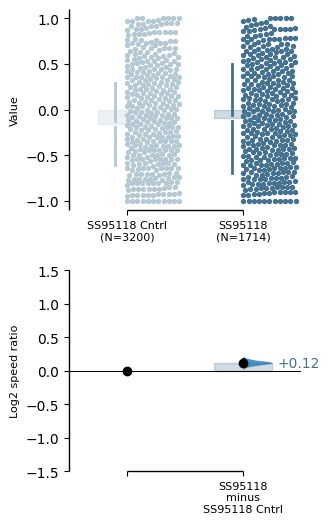

In [25]:
full_light = df[df["light_intensity"] == "Full"].reset_index(drop=True)
singleplottingdabest(full_light, basegenotype,'pi_smoothed_Pattern 01').hedges_g.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, contrast_marker_size=6, 
                                                                      custom_palette="Paired", contrast_label="Log2 speed ratio", contrast_ylim=(-1.5,1.5));

## No compiled .csv file

In [ ]:
# IF no current file already

osarAnalysis = osar.osar(baseDirectory_OSAR,
                        # border_shift_mm = 1.5,  
                        # countlog_folder = "countlog_Full Only",         
                        # countlog_folder = "countlog_Half and Full",
                         driver = basegenotype)

Creating borders for each fly...
Done.

Processing CSV 55 of 55
Summarising results for all flies...
All done.


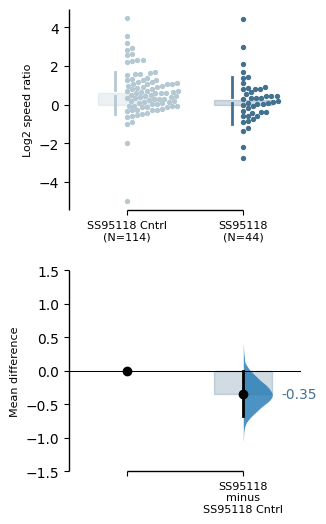

In [7]:
full_light = osarAnalysis.results[osarAnalysis.results['light_intensity'] == "Full"]
singleplottingdabest(full_light, basegenotype,'log2_speed_ratio_Pattern 01').mean_diff.plot(float_contrast=False, fontsize_rawylabel=8, fontsize_rawxlabel=8, 
                                                                      fontsize_contrastxlabel=8, fontsize_contrastylabel=8, raw_marker_size=2, es_marker_size=6, 
                                                                      custom_palette="Paired", swarm_label="Log2 speed ratio", contrast_ylim=(-1.5,1.5));